In [30]:
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader
import sys
sys.path.append("C:/Users/tjsss/OneDrive/Desktop/machine learning/mlFromScratch")
import torchvision
from torchvision import transforms
from utils.utilities import add_to_class, HyperParameters
from fashion_mnist_loader import FashionMNIST
from softmaxClassifier import Classifier
from sklearn.metrics import accuracy_score

## load mnist dataset

In [31]:
path = 'C:/Users/tjsss/OneDrive/Desktop/machine learning/mlFromScratch/fashionMNISTdataset'
data = FashionMNIST(path = path)

In [32]:
x,y = next(iter(data.get_data(True)))
print(x.shape, y.shape, x.dtype, y.dtype)

torch.Size([16, 1, 32, 32]) torch.Size([16]) torch.float32 torch.int64


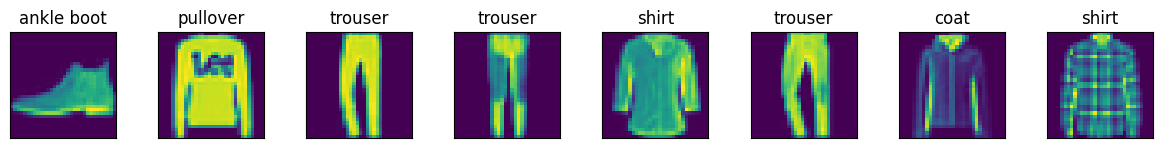

In [33]:
batch = next(iter(data.get_data(train=False)))
data.visualize(batch = batch)

In [34]:
train_loader = data.get_data(train=True, batch_size = 16)
val_loader = data.get_data(train = False, batch_size = 16)

In [35]:
softmax_reg = Classifier(32, 10)

In [36]:
softmax_reg.train(train_loader=train_loader, val_loader=val_loader, epochs = 10)

---------- 1 ----------
Mean Train Loss in Epoch: 1 is: 0.6938
Mean Val Loss in Epoch: 1 is: 0.5775
---------- 2 ----------
Mean Train Loss in Epoch: 2 is: 0.5292
Mean Val Loss in Epoch: 2 is: 0.5266
---------- 3 ----------
Mean Train Loss in Epoch: 3 is: 0.4943
Mean Val Loss in Epoch: 3 is: 0.5137
---------- 4 ----------
Mean Train Loss in Epoch: 4 is: 0.4760
Mean Val Loss in Epoch: 4 is: 0.5050
---------- 5 ----------
Mean Train Loss in Epoch: 5 is: 0.4629
Mean Val Loss in Epoch: 5 is: 0.5050
---------- 6 ----------
Mean Train Loss in Epoch: 6 is: 0.4538
Mean Val Loss in Epoch: 6 is: 0.4839
---------- 7 ----------
Mean Train Loss in Epoch: 7 is: 0.4471
Mean Val Loss in Epoch: 7 is: 0.4778
---------- 8 ----------
Mean Train Loss in Epoch: 8 is: 0.4421
Mean Val Loss in Epoch: 8 is: 0.4717
---------- 9 ----------
Mean Train Loss in Epoch: 9 is: 0.4374
Mean Val Loss in Epoch: 9 is: 0.4652
---------- 10 ----------
Mean Train Loss in Epoch: 10 is: 0.4336
Mean Val Loss in Epoch: 10 is: 0.46

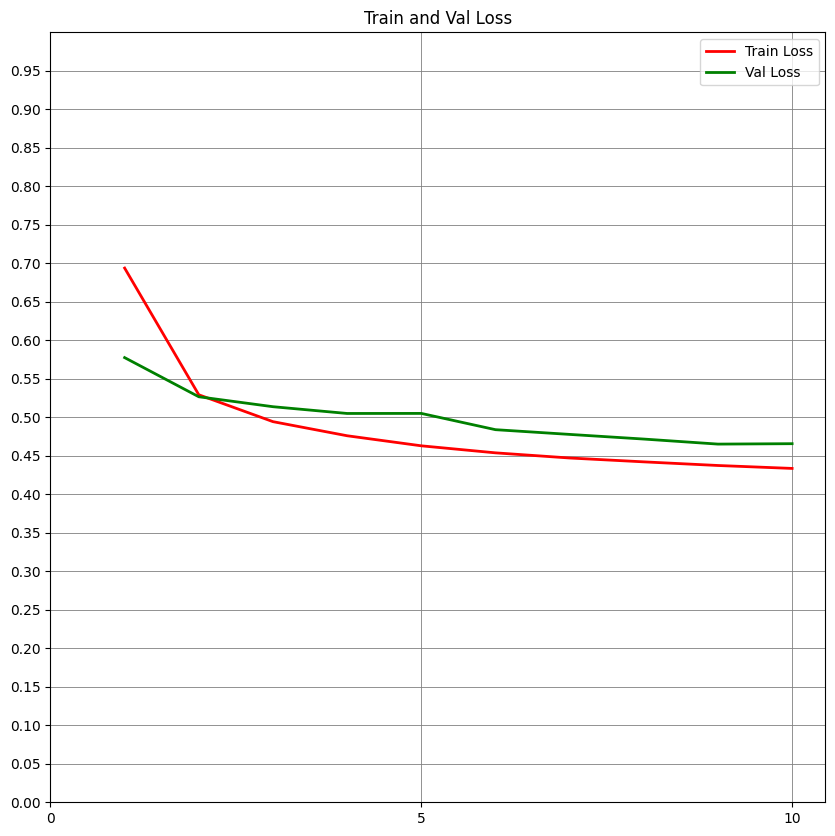

In [37]:
softmax_reg.history()

In [38]:
x,y = next(iter(val_loader))
data.text_labels(np.arange(10))

['t-shirt',
 'trouser',
 'pullover',
 'dress',
 'coat',
 'sandal',
 'shirt',
 'sneaker',
 'bag',
 'ankle boot']

In [39]:
['t-shirt'] == data.text_labels([y[1]])

False

In [43]:
n = len(val_loader)
total  = 0
score = 0
for x_batch, y_batch in val_loader:
    for i in range(x_batch.shape[0]):
        pred = torch.tensor(softmax_reg.predict(x_batch[i:i+1]))
        truth = y_batch[i]
        total+=1

        if pred == truth:
            score += 1
            
        
print("Accuracy: ", (score/total)*100)
   

Accuracy:  83.71


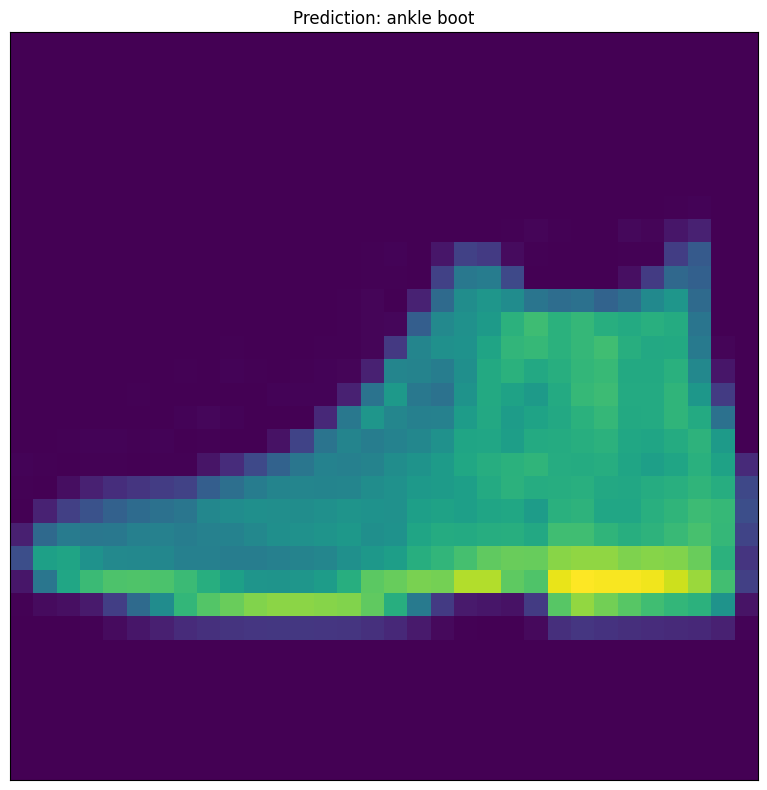

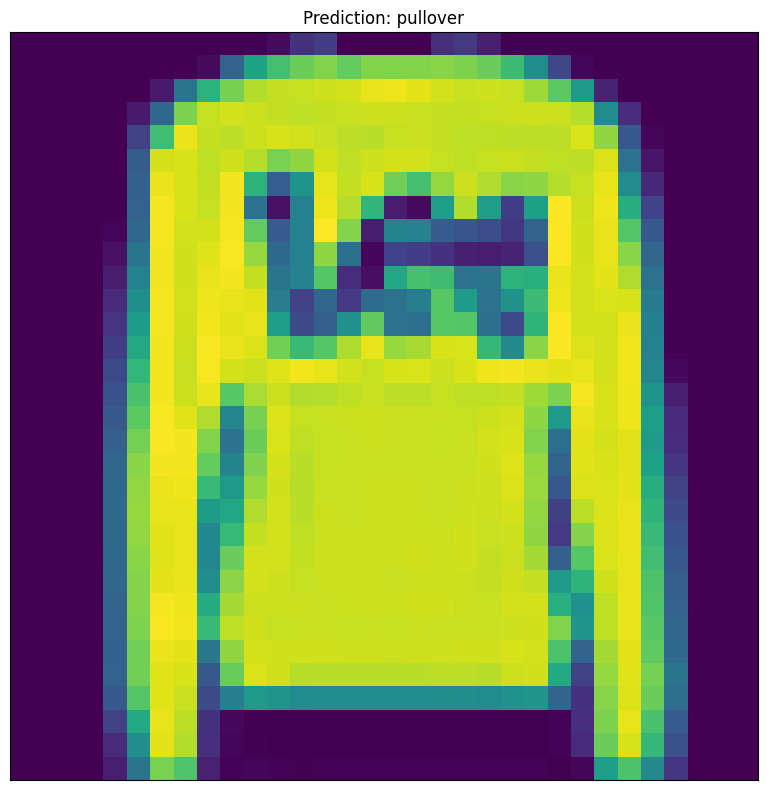

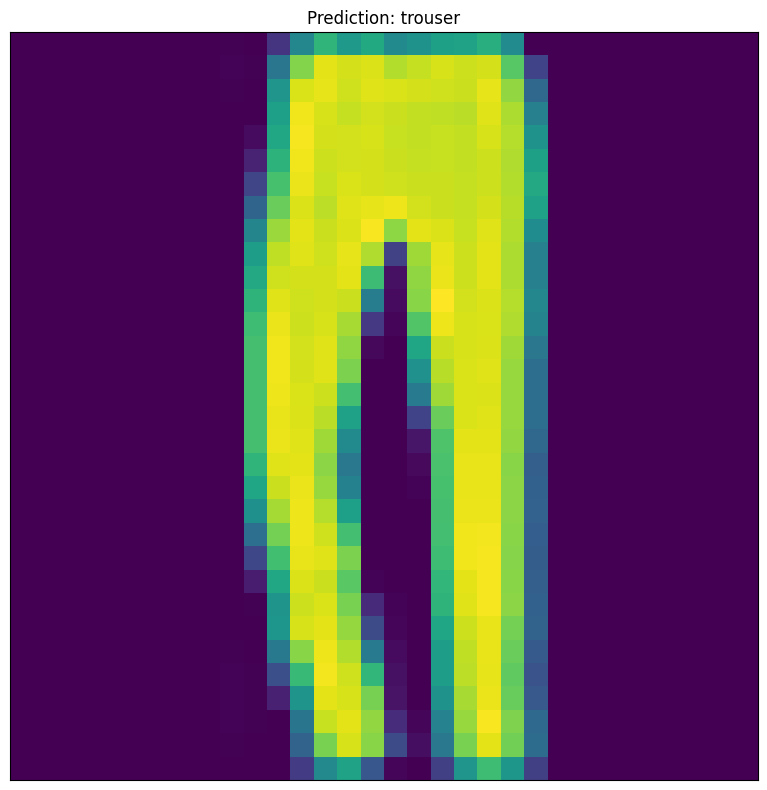

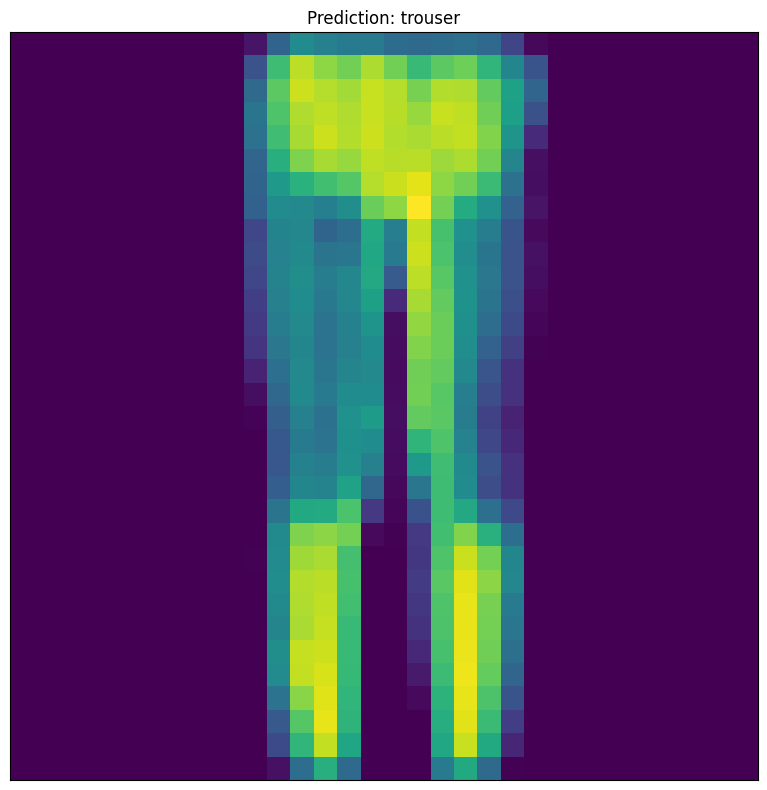

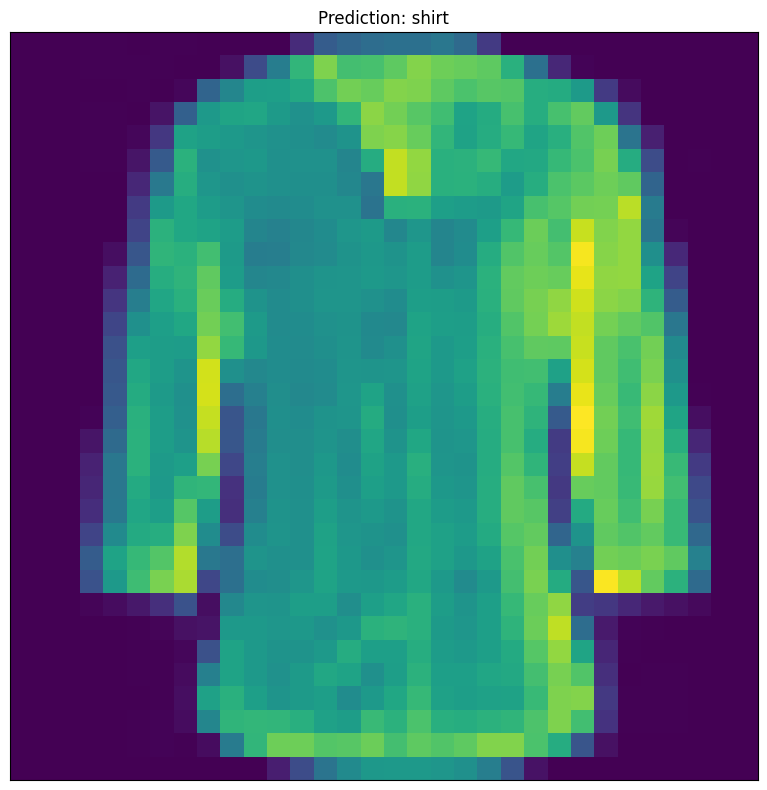

In [42]:
n = 5
for n in range(n):
    softmax_reg.plot_predict(x[n])